# Half-space TDEM: the time-stepping fix & validation — fully reproducible report

Reproduces **every figure and number** in `report.pdf`, **fix first**. Section 1 gives the one-line
`forward_farquarson.py` change and its result; Sections 2–5 are the analysis that justifies it.

**Structure:** *compute* cells (analysis / solves) are kept separate from *figure* cells — every plot
lives in its own standalone cell that only reads variables computed above.

**Runtime:** ~6–7 min (seven 3D octree solves, two on a finer mesh). Sections 2 and 5 are the heavy part.

| Report figure | Section here |
|---|---|
| `fig_farquarson_before_after` | 1 |
| `fig_convergence_timesteps`, `fig_before_after_fix` | 2 |
| `fig_diagnosis_1d_vs_3d` | 3 |
| `fig_loop_geometry` | 4 |
| `fig_timestep_refinement` | 5 |

> **Label note:** in the original `comparision.ipynb`, the curve labelled `analytic-half` (`dpred`) is
> actually the SimPEG **1D layered** result — the *accurate* one. `simpeg-half` is the coarse 3D run.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time as _time; warnings.filterwarnings("ignore")
from scipy.special import erf
from scipy.constants import mu_0

from discretize import TensorMesh
from discretize import utils as dis_utils
from discretize.utils import volume_average
from simpeg import utils, maps
from simpeg.electromagnetics import time_domain
import simpeg.electromagnetics.time_domain as tdem


def get_solver():
    '''Pick whatever fast direct solver is installed (Pardiso > Mumps > LU).'''
    from scipy.sparse import eye
    probe = eye(2).tocsr()
    for name in ("Pardiso", "Mumps"):
        try:
            import pymatsolver
            S = getattr(pymatsolver, name); S(probe); return S
        except Exception:
            continue
    from pymatsolver import SolverLU
    return SolverLU

Solver = get_solver()
print("Using direct solver:", Solver.__name__)

Using direct solver: Mumps


In [2]:
# survey geometry: 100 x 100 m square loop, central dBz/dt receiver, step-off
dx = dy = 100.0
z_surface = 0.0
source_locations = np.array([[-dx/2, -dy/2, 0.], [-dx/2,  dy/2, 0.],
                             [ dx/2,  dy/2, 0.], [ dx/2, -dy/2, 0.], [-dx/2, -dy/2, 0.]])
rx_locations = np.array([[0., 0., 0.]])
times   = np.logspace(-4, -2, 21)
sigma_hs = 0.1
a = np.sqrt(dx*dy/np.pi)     # equal-area circular-loop radius
print(f"equal-area radius a = {a:.3f} m")

equal-area radius a = 56.419 m


In [3]:
# Ward & Hohmann analytic reference, and the SimPEG 1D layered reference solutions
def analytic_halfspace(times, sigma, radius):
    '''|dBz/dt| at loop centre on a homogeneous half-space, step-off (Ward & Hohmann 1988).'''
    theta = np.sqrt(mu_0 * sigma / (4.0 * times)); ta = theta * radius
    return np.abs(1.0/(sigma*radius**3) * (3*erf(ta) - 2/np.sqrt(np.pi)*ta*(3+2*ta**2)*np.exp(-ta**2)))


def run_1d(loop="square", n_points_per_path=10, radius=None):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locations[0], times, orientation="z")
    if loop == "square":
        src = tdem.sources.LineCurrent([rx], location=source_locations,
                                       waveform=tdem.sources.StepOffWaveform())
        sim = tdem.Simulation1DLayered(survey=tdem.Survey([src]), sigmaMap=maps.IdentityMap(nP=1),
                                       n_points_per_path=n_points_per_path)
    else:
        src = tdem.sources.CircularLoop([rx], location=np.r_[0., 0., 0.], radius=radius or a,
                                        waveform=tdem.sources.StepOffWaveform())
        sim = tdem.Simulation1DLayered(survey=tdem.Survey([src]), sigmaMap=maps.IdentityMap(nP=1))
    return np.abs(sim.dpred(np.r_[sigma_hs]))

d_anal      = analytic_halfspace(times, sigma_hs, a)
d_1d_square = run_1d("square")
d_1d_circle = run_1d("circle")
print("analytic + 1D layered references computed.")

analytic + 1D layered references computed.


## 1. The fix (applied to `forward_farquarson.py`)

`forward_farquarson.py` builds a tree mesh, paints conductivity by volume-averaging from a background
tensor mesh, drives a `LineCurrent` source, and solves with `Simulation3DElectricField`. Its original
time-step ramp doubles each level (55 steps) — too coarse for backward-Euler, biasing `dBz/dt` high.
The one-line change:

```
- generate_time_steps(n_constant_steps=11, increase_rate=2,   start_time_step=1e-6, n_per_step=5)  # 55 steps
+ generate_time_steps(n_constant_steps=26, increase_rate=1.4, start_time_step=3e-7, n_per_step=6)  # 156 steps
```

brings the 3D octree to within ~±2% of analytic on the **same** mesh. The committed
`half_tem_faquarson.csv` was regenerated accordingly (`.orig_backup` keeps the original).


In [4]:
# --- 3D octree machinery (mirrors forward_farquarson.py); results cached in R[...] ---
hx = np.ones(40)*5; hy = np.ones(30)*5; hz = np.ones(31)*5
mesh_tensor = TensorMesh([hx, hy, hz], x0=[-hx.sum()/2, -hy.sum()/2, -hz.sum()+5])
active = mesh_tensor.cell_centers[:, 2] < 0.0
sigma_tensor = np.ones(mesh_tensor.n_cells)*sigma_hs; sigma_tensor[~active] = 1e-8


def build_octree(h):
    buf = 200
    locs = np.vstack((source_locations, rx_locations))
    x = np.linspace(locs[:, 0].min()-buf, locs[:, 0].max()+buf)
    y = np.linspace(locs[:, 1].min()-buf, locs[:, 1].max()+buf)
    dem = utils.ndgrid(x, y, np.r_[z_surface])
    mesh = dis_utils.mesh_builder_xyz(dem, h, padding_distance=[5000, 5000, 5000],
                                      base_mesh=None, depth_core=100, mesh_type='tree')
    mesh.refine_surface(dem, -1, padding_cells_by_level=[[0, 0, 1], [0, 0, 15]], finalize=False)
    mesh.refine_line(source_locations, -1, finalize=False)
    mesh.refine_points(rx_locations, -1, finalize=False)
    mesh.finalize()
    return mesh


def make_time_steps(n_constant_steps, increase_rate, start_time_step, n_per_step):
    return np.hstack([np.ones(n_per_step)*start_time_step*increase_rate**i
                      for i in range(n_constant_steps)])


R = {}   # cache of 3D results, keyed by config name

def run_3d(name, h, ts):
    t0 = _time.time(); mesh = build_octree(h)
    sig = volume_average(mesh_tensor, mesh) @ sigma_tensor
    rx = time_domain.Rx.PointMagneticFluxTimeDerivative(rx_locations, times, "z")
    src = time_domain.Src.LineCurrent([rx], location=source_locations)
    sim = time_domain.Simulation3DElectricField(
        mesh, sigmaMap=maps.IdentityMap(nP=mesh.n_cells),
        survey=time_domain.Survey([src]), time_steps=ts, solver=Solver)
    R[name] = np.abs(sim.dpred(sig))
    print(f"  [{name:10s}] {mesh.n_cells/1e3:4.0f}k cells, {len(ts):3d} steps, "
          f"{_time.time()-t0:3.0f}s | mean/analytic = {(R[name]/d_anal).mean():.3f}")
    return R[name]

# time-step ramps used throughout (matches forward_farquarson.py before/after, plus finer ones)
TS = {
    "baseline":  make_time_steps(11, 2.00, 1e-6, 5),   # original, x2,    55 steps
    "time_fine": make_time_steps(18, 1.50, 1e-6, 5),   #           x1.5,  90 steps
    "fix":       make_time_steps(26, 1.40, 3e-7, 6),   # the fix,  x1.4, 156 steps
    "r130":      make_time_steps(33, 1.30, 1e-7, 6),   #           x1.3, 198 steps
    "r125":      make_time_steps(40, 1.25, 7e-8, 8),   #           x1.25,320 steps
}
print("machinery ready.")

machinery ready.


In [5]:
# COMPUTE: original vs fixed time-stepping on the [10,10,5] mesh
print("3D octree solves:")
run_3d("baseline", [10, 10, 5], TS["baseline"])   # original time-stepping
run_3d("fix",      [10, 10, 5], TS["fix"])        # corrected time-stepping

3D octree solves:


  [baseline  ]   28k cells,  55 steps,  17s | mean/analytic = 1.187


  [fix       ]   28k cells, 156 steps,  40s | mean/analytic = 0.996


array([2.40574939e-05, 1.57703872e-05, 1.00916382e-05, 6.28346954e-06,
       3.81424735e-06, 2.29086000e-06, 1.35345562e-06, 7.89752842e-07,
       4.57487204e-07, 2.63415701e-07, 1.50646060e-07, 8.56706045e-08,
       4.86167005e-08, 2.74320709e-08, 1.54286612e-08, 8.67775910e-09,
       4.84703682e-09, 2.70659311e-09, 1.52346680e-09, 8.62573975e-10,
       4.90554816e-10])

In [6]:
# COMPUTE: confirm the in-notebook runs reproduce the committed CSV files
import os
for fname, key in [("half_tem_faquarson.csv.orig_backup", "baseline"),
                   ("half_tem_faquarson.csv", "fix")]:
    if os.path.exists(fname):
        csv = np.abs(pd.read_csv(fname)["voltage_V_Am2"].values)
        print(f"{fname:36s}: max diff vs R['{key}'] = {np.abs(R[key]/csv-1).max()*100:.2f} %")

half_tem_faquarson.csv.orig_backup  : max diff vs R['baseline'] = 0.07 %
half_tem_faquarson.csv              : max diff vs R['fix'] = 0.08 %


### Figure 1 (report Fig. 1) — Farquharson solution before/after the fix vs Ward & Hohmann

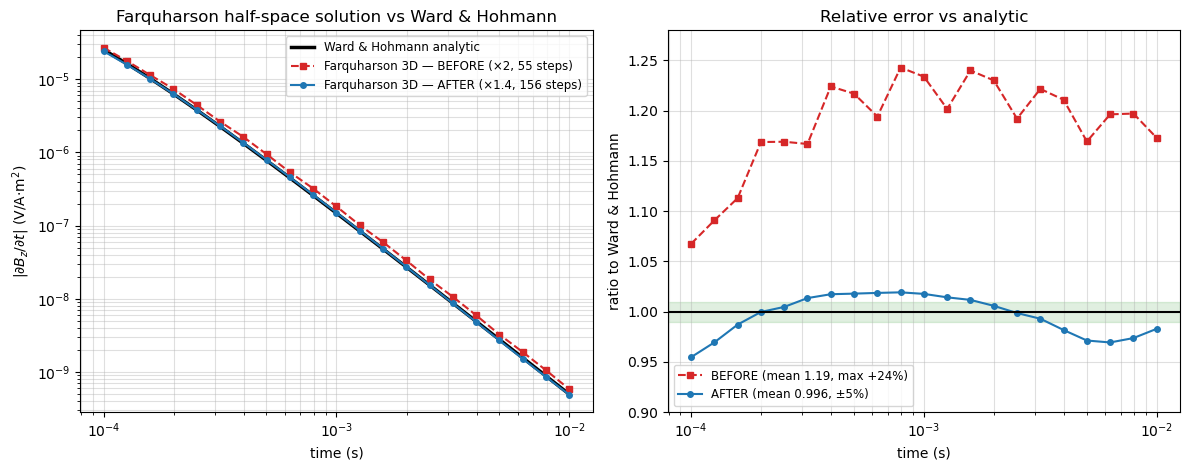

In [7]:
# FIGURE ONLY
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].loglog(times, d_anal, 'k-', lw=2.5, label='Ward & Hohmann analytic')
ax[0].loglog(times, R["baseline"], 'C3s--', ms=5, label='Farquharson 3D — BEFORE (×2, 55 steps)')
ax[0].loglog(times, R["fix"], 'C0o-', ms=4, label='Farquharson 3D — AFTER (×1.4, 156 steps)')
ax[0].set_xlabel('time (s)'); ax[0].set_ylabel(r'$|\partial B_z/\partial t|$ (V/A·m$^2$)')
ax[0].grid(True, which='both', alpha=.4); ax[0].legend(fontsize=8.5)
ax[0].set_title('Farquharson half-space solution vs Ward & Hohmann')
ax[1].semilogx(times, R["baseline"]/d_anal, 'C3s--', ms=5,
               label=f'BEFORE (mean {(R["baseline"]/d_anal).mean():.2f}, max +{(R["baseline"]/d_anal-1).max()*100:.0f}%)')
ax[1].semilogx(times, R["fix"]/d_anal, 'C0o-', ms=4,
               label=f'AFTER (mean {(R["fix"]/d_anal).mean():.3f}, ±{np.abs(R["fix"]/d_anal-1).max()*100:.0f}%)')
ax[1].axhspan(0.99, 1.01, color='green', alpha=.12); ax[1].axhline(1, color='k', lw=1.5)
ax[1].set_ylim(0.9, 1.28); ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('ratio to Ward & Hohmann')
ax[1].grid(True, which='both', alpha=.4); ax[1].legend(fontsize=8.5); ax[1].set_title('Relative error vs analytic')
plt.tight_layout(); plt.savefig('fig_farquarson_before_after.png', dpi=130); plt.show()

## 2. Why it works: time-stepping, not mesh  *(heavy: 3 more 3D solves, ~3 min)*

Refining the **time-steps** on the original mesh drives the error to zero; refining the **mesh**
(3.3× cells) on the original time-steps barely helps.


In [8]:
# COMPUTE: convergence study
run_3d("time_fine", [10, 10, 5],  TS["time_fine"])   # finer time, original mesh
run_3d("mesh_fine", [5, 5, 2.5],  TS["baseline"])    # original time, finer mesh  (~1 min)
run_3d("mesh_time", [5, 5, 2.5],  TS["time_fine"])   # both refined               (~2 min)

print("\nmean ratio to analytic:")
for k in ["baseline", "time_fine", "fix", "mesh_fine", "mesh_time"]:
    r = R[k]/d_anal
    print(f"  {k:10s}: mean {r.mean():.3f}  range {r.min():.3f}-{r.max():.3f}")

  [time_fine ]   28k cells,  90 steps,  27s | mean/analytic = 1.053


  [mesh_fine ]   95k cells,  55 steps,  63s | mean/analytic = 1.156


  [mesh_time ]   95k cells,  90 steps, 102s | mean/analytic = 1.027

mean ratio to analytic:
  baseline  : mean 1.187  range 1.067-1.243
  time_fine : mean 1.053  range 0.992-1.082
  fix       : mean 0.996  range 0.955-1.019
  mesh_fine : mean 1.156  range 1.078-1.224
  mesh_time : mean 1.027  range 0.989-1.092


### Figure 2 (report Fig. 2) — convergence study

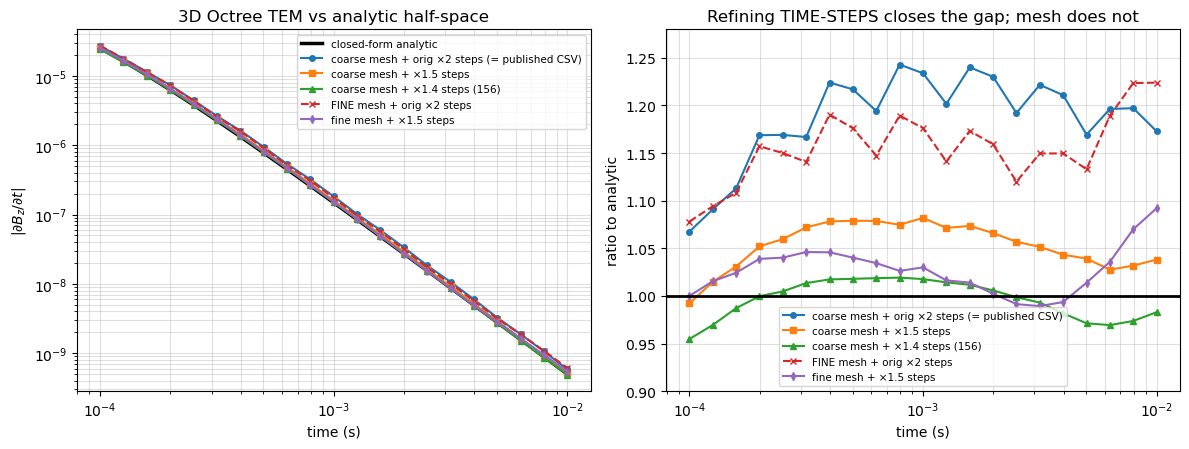

In [9]:
# FIGURE ONLY
order = [("baseline","coarse mesh + orig ×2 steps (= published CSV)","o-"),
         ("time_fine","coarse mesh + ×1.5 steps","s-"),
         ("fix","coarse mesh + ×1.4 steps (156)","^-"),
         ("mesh_fine","FINE mesh + orig ×2 steps","x--"),
         ("mesh_time","fine mesh + ×1.5 steps","d-")]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].loglog(times, d_anal, 'k-', lw=2.5, label='closed-form analytic')
for k, lab, st in order:
    ax[0].loglog(times, R[k], st, ms=4, label=lab)
ax[0].set_xlabel('time (s)'); ax[0].set_ylabel(r'$|\partial B_z/\partial t|$')
ax[0].grid(True, which='both', alpha=.4); ax[0].legend(fontsize=7.5)
ax[0].set_title('3D Octree TEM vs analytic half-space')
for k, lab, st in order:
    ax[1].semilogx(times, R[k]/d_anal, st, ms=4, label=lab)
ax[1].axhline(1, color='k', lw=2); ax[1].set_ylim(0.9, 1.28)
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('ratio to analytic'); ax[1].grid(True, which='both', alpha=.4)
ax[1].legend(fontsize=7.5); ax[1].set_title('Refining TIME-STEPS closes the gap; mesh does not')
plt.tight_layout(); plt.savefig('fig_convergence_timesteps.png', dpi=130); plt.show()

### Figure 3 (report Fig. 3) — before/after with the 1D layered solution overlaid

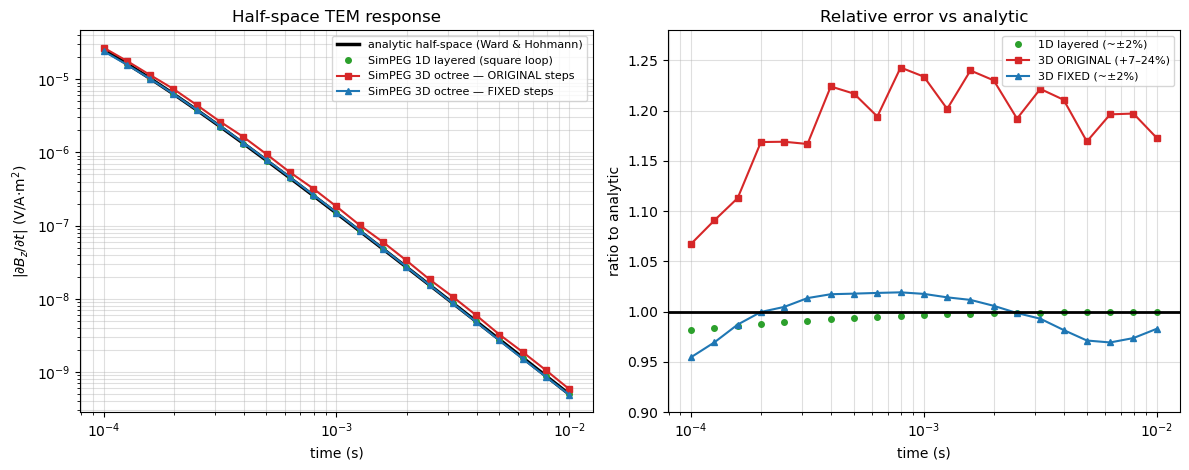

In [10]:
# FIGURE ONLY
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].loglog(times, d_anal, 'k-', lw=2.5, label='analytic half-space (Ward & Hohmann)')
ax[0].loglog(times, d_1d_square, 'C2o', ms=4, label='SimPEG 1D layered (square loop)')
ax[0].loglog(times, R["baseline"], 'C3s-', ms=4, label='SimPEG 3D octree — ORIGINAL steps')
ax[0].loglog(times, R["fix"], 'C0^-', ms=4, label='SimPEG 3D octree — FIXED steps')
ax[0].set_xlabel('time (s)'); ax[0].set_ylabel(r'$|\partial B_z/\partial t|$ (V/A·m$^2$)')
ax[0].grid(True, which='both', alpha=.4); ax[0].legend(fontsize=8); ax[0].set_title('Half-space TEM response')
ax[1].semilogx(times, d_1d_square/d_anal, 'C2o', ms=4, label='1D layered (~±2%)')
ax[1].semilogx(times, R["baseline"]/d_anal, 'C3s-', ms=4, label='3D ORIGINAL (+7–24%)')
ax[1].semilogx(times, R["fix"]/d_anal, 'C0^-', ms=4, label='3D FIXED (~±2%)')
ax[1].axhline(1, color='k', lw=2); ax[1].set_ylim(0.9, 1.28)
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('ratio to analytic')
ax[1].grid(True, which='both', alpha=.4); ax[1].legend(fontsize=8); ax[1].set_title('Relative error vs analytic')
plt.tight_layout(); plt.savefig('fig_before_after_fix.png', dpi=130); plt.show()

## 3. The 1D layered solution is the correct reference

`Simulation1DLayered` matches the closed-form Ward & Hohmann response to ~5 sig figs (circular loop);
it is the trustworthy reference. The ~1.8% for the square loop is geometry (Section 4).


In [11]:
# COMPUTE / report the 1D validation numbers (references computed in Setup)
print(f"1D circular loop vs analytic : max error = {np.abs(d_1d_circle/d_anal-1).max()*100:.4f} %")
print(f"1D square   loop vs analytic : max error = {np.abs(d_1d_square/d_anal-1).max()*100:.2f} % "
      f"(square-vs-circle geometry; see Section 4)")

1D circular loop vs analytic : max error = 0.0007 %
1D square   loop vs analytic : max error = 1.82 % (square-vs-circle geometry; see Section 4)


### Figure 4 (report Fig. 4) — localizing the discrepancy: 1D correct, original 3D off

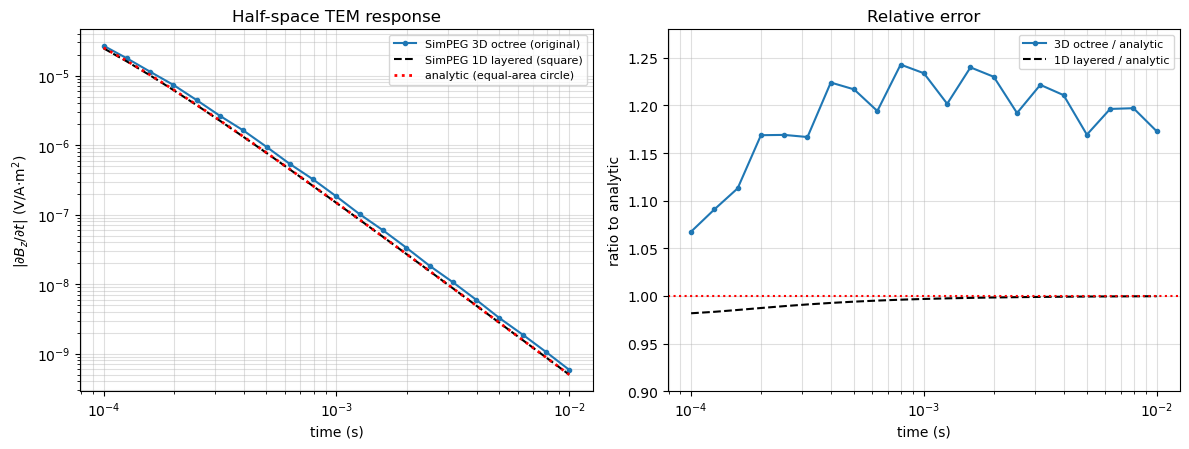

In [12]:
# FIGURE ONLY
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].loglog(times, R["baseline"], 'C0-o', ms=3, label='SimPEG 3D octree (original)')
ax[0].loglog(times, d_1d_square, 'k--', label='SimPEG 1D layered (square)')
ax[0].loglog(times, d_anal, 'r:', lw=2, label='analytic (equal-area circle)')
ax[0].set_xlabel('time (s)'); ax[0].set_ylabel(r'$|\partial B_z/\partial t|$ (V/A·m$^2$)')
ax[0].grid(True, which='both', alpha=.4); ax[0].legend(fontsize=8); ax[0].set_title('Half-space TEM response')
ax[1].semilogx(times, R["baseline"]/d_anal, 'C0-o', ms=3, label='3D octree / analytic')
ax[1].semilogx(times, d_1d_square/d_anal, 'k--', label='1D layered / analytic')
ax[1].axhline(1, color='r', ls=':'); ax[1].set_ylim(0.9, 1.28)
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('ratio to analytic')
ax[1].grid(True, which='both', alpha=.4); ax[1].legend(fontsize=8); ax[1].set_title('Relative error')
plt.tight_layout(); plt.savefig('fig_diagnosis_1d_vs_3d.png', dpi=130); plt.show()

## 4. The 1.8% square-vs-circle difference is geometry, not error

The wire integration is converged (refining `n_points_per_path` changes the result by <0.07%), and a
circle reproduces the analytic to 0.0007%. There is no elementary closed form for a square loop — the
"analytic" curve is a *circle*. A square matches its **equal-area** circle only in the late-time
point-dipole limit; at early time it depends on the actual distance to the wire.


In [13]:
# COMPUTE: wire-integration convergence + square vs three reference circles
sq_ref = run_1d("square", n_points_per_path=200)   # converged wire-integration reference
for npp in (3, 10, 40, 100):
    d = run_1d("square", n_points_per_path=npp)
    print(f"  n_points_per_path={npp:3d}: max diff vs converged (200 pts) = {np.abs(d/sq_ref-1).max()*100:.4f} %")

S    = run_1d("square", n_points_per_path=20)
c_in = run_1d("circle", radius=50.0)     # inscribed
c_eq = run_1d("circle", radius=a)        # equal-area
c_out= run_1d("circle", radius=70.71)    # circumscribed
print("geometry arrays computed.")

  n_points_per_path=  3: max diff vs converged (200 pts) = 0.0671 %
  n_points_per_path= 10: max diff vs converged (200 pts) = 0.0000 %
  n_points_per_path= 40: max diff vs converged (200 pts) = 0.0000 %
  n_points_per_path=100: max diff vs converged (200 pts) = 0.0000 %
geometry arrays computed.


### Figure 5 (report Fig. 5) — square vs inscribed / equal-area / circumscribed circles

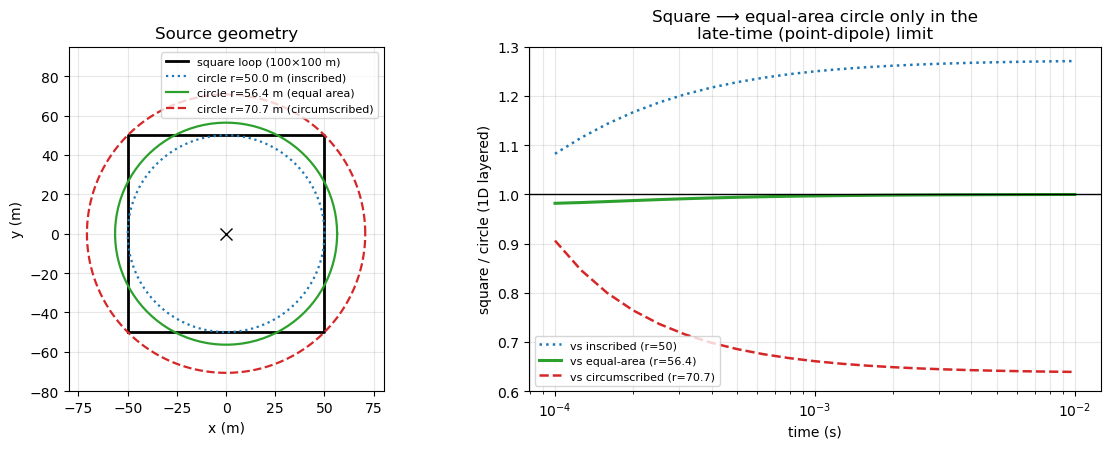

In [14]:
# FIGURE ONLY
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(source_locations[:, 0], source_locations[:, 1], 'k-', lw=2, label='square loop (100×100 m)')
th = np.linspace(0, 2*np.pi, 200)
for rad, c, ls, tag in [(50, 'C0', ':', 'inscribed'), (a, 'C2', '-', 'equal area'), (70.71, 'C3', '--', 'circumscribed')]:
    ax[0].plot(rad*np.cos(th), rad*np.sin(th), c, ls=ls, lw=1.6, label=f'circle r={rad:.1f} m ({tag})')
ax[0].plot(0, 0, 'kx', ms=8); ax[0].set_aspect(1); ax[0].set_xlim(-80, 80); ax[0].set_ylim(-80, 95)
ax[0].set_xlabel('x (m)'); ax[0].set_ylabel('y (m)'); ax[0].legend(fontsize=8, loc='upper right')
ax[0].grid(alpha=.3); ax[0].set_title('Source geometry')
ax[1].semilogx(times, S/c_in, 'C0:', lw=1.8, label='vs inscribed (r=50)')
ax[1].semilogx(times, S/c_eq, 'C2-', lw=2.2, label='vs equal-area (r=56.4)')
ax[1].semilogx(times, S/c_out, 'C3--', lw=1.8, label='vs circumscribed (r=70.7)')
ax[1].axhline(1, color='k', lw=1); ax[1].set_ylim(0.6, 1.3)
ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('square / circle (1D layered)')
ax[1].grid(True, which='both', alpha=.3); ax[1].legend(fontsize=8)
ax[1].set_title('Square ⟶ equal-area circle only in the\nlate-time (point-dipole) limit')
plt.tight_layout(); plt.savefig('fig_loop_geometry.png', dpi=130); plt.show()

## 5. What it takes to reach <1% — and why "more time-steps" backfires  *(heavy: 2 more solves, ~2 min)*

Scored against the correct same-geometry reference (1D layered **square** loop): the fix sits at mean
+0.2% (max 3%), but pushing the steps finer overshoots — exposing a spatial floor a few % low. The
fix's great mean is partly a cancellation of a temporal high-bias and a spatial low-bias.


In [15]:
# COMPUTE: push time-stepping past the fix
run_3d("r130", [10, 10, 5], TS["r130"])   # ×1.3, 198 steps
run_3d("r125", [10, 10, 5], TS["r125"])   # ×1.25, 320 steps

print("\nvs 1D layered SQUARE reference:")
for k, lab in [("fix","×1.4, 156 (fix)"), ("r130","×1.3, 198"), ("r125","×1.25, 320")]:
    e = R[k]/d_1d_square - 1
    print(f"  {lab:16s}: mean {e.mean()*100:+.1f}%  max |err| {np.abs(e).max()*100:.1f}%")

  [r130      ]   28k cells, 198 steps,  53s | mean/analytic = 0.971


  [r125      ]   28k cells, 320 steps,  65s | mean/analytic = 0.941

vs 1D layered SQUARE reference:
  ×1.4, 156 (fix) : mean +0.2%  max |err| 3.0%
  ×1.3, 198       : mean -2.4%  max |err| 5.8%
  ×1.25, 320      : mean -5.4%  max |err| 9.0%


### Figure 6 (report Fig. 6) — refining time-steps shifts every channel downward

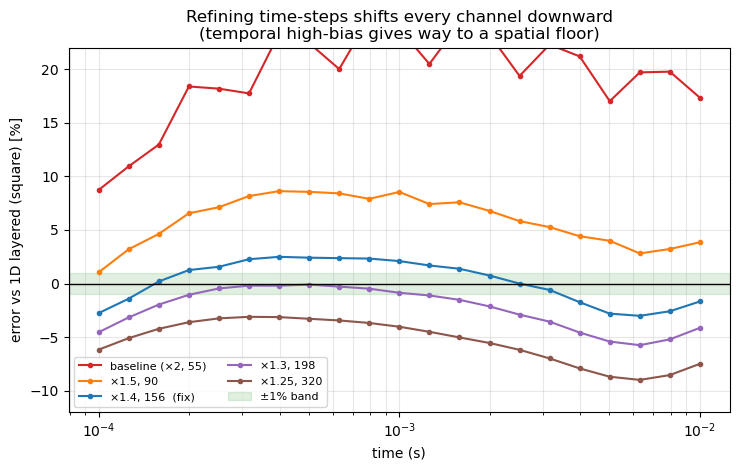

In [16]:
# FIGURE ONLY
series = [('baseline (×2, 55)', R["baseline"], 'C3'),
          ('×1.5, 90', R["time_fine"], 'C1'),
          ('×1.4, 156  (fix)', R["fix"], 'C0'),
          ('×1.3, 198', R["r130"], 'C4'),
          ('×1.25, 320', R["r125"], 'C5')]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for lab, d, c in series:
    ax.semilogx(times, (d/d_1d_square-1)*100, 'o-', ms=3, color=c, label=lab)
ax.axhspan(-1, 1, color='green', alpha=.12, label='±1% band'); ax.axhline(0, color='k', lw=1)
ax.set_xlabel('time (s)'); ax.set_ylabel('error vs 1D layered (square) [%]'); ax.set_ylim(-12, 22)
ax.legend(fontsize=8, ncol=2); ax.grid(True, which='both', alpha=.3)
ax.set_title('Refining time-steps shifts every channel downward\n(temporal high-bias gives way to a spatial floor)')
plt.tight_layout(); plt.savefig('fig_timestep_refinement.png', dpi=130); plt.show()

## 6. Conclusions

1. **The fix is one line** (`×2`→`×1.4` time-step ramp): the 3D octree goes from +7–24% to ~±2% on the
   same mesh.
2. **Time-stepping, not mesh** — refining the mesh alone barely helps.
3. **SimPEG's 1D layered solution was never the problem** — it matches Ward & Hohmann (5 sig figs).
4. **The ~1.8% square-vs-circle difference is genuine geometry.** Reaching <1% at every channel needs
   temporal *and* spatial errors below 1% independently — a convergence study, not a one-line change.

All six figures above are written to PNGs identical to those embedded in `report.pdf`.
